### **1. Download the SQLite database**

In [1]:
import pandas as pd
import sqlite3
import json

#### 1.1. Load the data from the db file

In [2]:
!pip install -q gdown
import gdown

file_id = "1az3kjSIseswW1y6YpiaUTWw-5zaPKyNV"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "file.db", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1az3kjSIseswW1y6YpiaUTWw-5zaPKyNV
From (redirected): https://drive.google.com/uc?id=1az3kjSIseswW1y6YpiaUTWw-5zaPKyNV&confirm=t&uuid=342e8b35-80e4-4960-b56d-d7e4cec0e91c
To: /content/file.db
100%|██████████| 137M/137M [00:01<00:00, 76.2MB/s]


'file.db'

In [3]:
conn = sqlite3.connect("file.db")
database_df = pd.read_sql("SELECT * FROM calculations", conn)
conn.close()

In [4]:
database_df.head()

,id,geometry_hash,params_hash,calculator,model,task,blob_data
0,1,f3d6504117074bd015755ce91997d51cc48064c643f475...,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,mace,medium,thermo,"{""xyz_file"": ""/lus/grand/projects/IQC/data/pho..."
1,2,6f07eb1c6bbdf174b517da29259c78026be9751d817d62...,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,mace,medium,thermo,"{""xyz_file"": ""/lus/grand/projects/IQC/data/pho..."
2,3,ce2adb0fa26c3adc08bed9b6f5ffd2b3d892c77ba2bc62...,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,mace,medium,thermo,"{""xyz_file"": ""/lus/grand/projects/IQC/data/pho..."
3,4,eb114e4946a0b84ac4ce86045f3a92897b451524afee11...,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,mace,medium,thermo,"{""xyz_file"": ""/lus/grand/projects/IQC/data/pho..."
4,5,af0dec21a8040794efc5818760e16029019c7f12b05edf...,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...,mace,medium,thermo,"{""xyz_file"": ""/lus/grand/projects/IQC/data/pho..."


#### 1.2. Turning blob_data into a pandas dataframe

In [5]:
blob_data_list = [json.loads(data) for data in database_df['blob_data']]
df = pd.DataFrame(blob_data_list)

In [6]:
df = df.rename(columns={
    'G_eV': 'G_eV (Gibbs Free Energy)',
    'H_eV': 'H_eV (Enthalpy)',
    'S_eV/K': 'S_eV/K (Entropy)',
    'E_ZPE_eV': 'E_ZPE_eV (Zero-Point Energy)'
})

In [7]:
df.head()

,xyz_file,date,mpi_size,mpi_rank,hostname,ase_version,task,calculator,params,warnings,...,vib_time,frequencies_cm^-1,vib_energies,number_of_imaginary,vibrational_frequencies_cm^-1,thermo_time,G_eV (Gibbs Free Energy),H_eV (Enthalpy),S_eV/K (Entropy),E_ZPE_eV (Zero-Point Energy)
0,/lus/grand/projects/IQC/data/photocarboxylatio...,2025-08-13 05:55:52,512,363,x1000c2s7b0n1,3.24.0,thermo,mace,,[],...,25.668625,"[{'real': 0.0, 'imag': 2.2749064103620245}, {'...","[{'real': 0.0, 'imag': 0.0002820524454406773},...",0,"[17.774678392133342, 20.299994231450366, 35.31...",0.152749,-220.596582,-218.333178,0.007591,5.710616
1,/lus/grand/projects/IQC/data/photocarboxylatio...,2025-08-13 06:10:23,512,363,x1000c2s7b0n1,3.24.0,thermo,mace,,[],...,49.501593,"[{'real': 0.0, 'imag': 53.60761545618465}, {'r...","[{'real': 0.0, 'imag': 0.006646497176670286}, ...",0,"[1.1527297802021648, 9.79563700260871, 11.7101...",0.245107,-318.538240,-315.800151,0.009184,9.131524
2,/lus/grand/projects/IQC/data/photocarboxylatio...,2025-08-13 05:52:35,512,363,x1000c2s7b0n1,3.24.0,thermo,mace,,[],...,31.155439,"[{'real': 0.0, 'imag': 63.90130641167223}, {'r...","[{'real': 0.0, 'imag': 0.00792275218803307}, {...",0,"[0.6677542075779875, 20.36781111143195, 23.186...",0.176202,-234.734594,-232.586061,0.007206,7.073553
3,/lus/grand/projects/IQC/data/photocarboxylatio...,2025-08-13 06:03:52,512,363,x1000c2s7b0n1,3.24.0,thermo,mace,,[],...,58.561132,"[{'real': 0.0, 'imag': 1.9451131105921224}, {'...","[{'real': 0.0, 'imag': 0.00024116328786199332}...",0,"[6.794277898663874, 12.562749978160213, 16.365...",0.291254,-323.736730,-320.875168,0.009598,9.852148
4,/lus/grand/projects/IQC/data/photocarboxylatio...,2025-08-13 05:59:57,512,363,x1000c2s7b0n1,3.24.0,thermo,mace,,[],...,40.283131,"[{'real': 0.0, 'imag': 4.182615803428762}, {'r...","[{'real': 0.0, 'imag': 0.0005185782634056439},...",0,"[17.60700100243319, 21.353926927144467, 29.156...",0.202883,-280.314148,-277.837983,0.008305,7.586848


#### 1.3. Exploring the data

In [8]:
df.columns

Index(['xyz_file', 'date', 'mpi_size', 'mpi_rank', 'hostname', 'ase_version',
       'task', 'calculator', 'params', 'warnings', 'error', 'number_of_atoms',
       'number_of_electrons', 'spin', 'formula', 'unique_name',
       'initial_smiles', 'initial_xyz', 'initial_symmetry',
       'initial_sym_number', 'initial_energy_eV', 'calculator_name', 'model',
       'opt_smiles', 'opt_xyz', 'opt_sym_number', 'opt_energy_eV',
       'smiles_changed', 'opt_time', 'opt_steps', 'opt_converged',
       'opt_forces', 'trajectory_file', 'optimized_geometry_file', 'opt_sym',
       'vib_time', 'frequencies_cm^-1', 'vib_energies', 'number_of_imaginary',
       'vibrational_frequencies_cm^-1', 'thermo_time',
       'G_eV (Gibbs Free Energy)', 'H_eV (Enthalpy)', 'S_eV/K (Entropy)',
       'E_ZPE_eV (Zero-Point Energy)'],
      dtype='object')

In [9]:
df.dtypes

,0
xyz_file,object
date,object
mpi_size,int64
mpi_rank,int64
hostname,object
ase_version,object
task,object
calculator,object
params,object
warnings,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6256 entries, 0 to 6255
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   xyz_file                       6256 non-null   object 
 1   date                           6256 non-null   object 
 2   mpi_size                       6256 non-null   int64  
 3   mpi_rank                       6256 non-null   int64  
 4   hostname                       6256 non-null   object 
 5   ase_version                    6256 non-null   object 
 6   task                           6256 non-null   object 
 7   calculator                     6256 non-null   object 
 8   params                         6256 non-null   object 
 9   warnings                       6256 non-null   object 
 10  error                          6256 non-null   object 
 11  number_of_atoms                6256 non-null   int64  
 12  number_of_electrons            6256 non-null   i

In [11]:
df.describe()

,mpi_size,mpi_rank,number_of_atoms,number_of_electrons,spin,initial_sym_number,initial_energy_eV,opt_sym_number,opt_energy_eV,opt_time,opt_steps,vib_time,number_of_imaginary,thermo_time,G_eV (Gibbs Free Energy),H_eV (Enthalpy),S_eV/K (Entropy),E_ZPE_eV (Zero-Point Energy)
count,6256.0,6256.000000,6256.000000,6256.000000,6256.0,6256.000000,6256.000000,6256.000000,6256.000000,6256.000000,6256.000000,6256.000000,6256.0,6256.000000,6256.000000,6256.000000,6256.000000,6256.000000
mean,512.0,251.919437,41.852302,205.581841,0.0,1.014066,-268.083820,1.012788,-271.084286,45.384736,280.655371,41.940712,0.0,0.214450,-264.902088,-262.486846,0.008101,7.823244
std,0.0,148.928536,9.636988,37.298738,0.0,0.117775,62.675385,0.112366,62.831872,24.578189,118.668784,19.815082,0.0,0.072300,60.989603,60.654093,0.001227,2.156110
min,512.0,0.000000,25.000000,124.000000,0.0,1.000000,-595.027118,1.000000,-598.152825,3.366238,36.000000,14.472491,0.0,0.099259,-581.411018,-577.427131,0.005141,4.096814
25%,512.0,120.750000,35.000000,180.000000,0.0,1.000000,-298.798833,1.000000,-301.764731,27.439486,182.000000,27.426103,0.0,0.163287,-294.797129,-292.269868,0.007216,6.288045
50%,512.0,251.000000,40.000000,196.000000,0.0,1.000000,-256.530940,1.000000,-259.877278,40.929357,283.000000,37.282494,0.0,0.198723,-253.377904,-251.053011,0.007893,7.541634
75%,512.0,381.000000,47.000000,226.000000,0.0,1.000000,-221.488600,1.000000,-224.762316,59.498881,366.000000,50.182164,0.0,0.244859,-220.261231,-217.930737,0.008786,8.887283
max,512.0,511.000000,93.000000,370.000000,0.0,2.000000,-160.385889,2.000000,-162.074173,158.762365,500.000000,176.190969,0.0,0.746970,-159.034154,-157.336699,0.013398,19.246261


### **2. Analysis**

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
# check how many are opt_converged

df['opt_converged'].sum()

np.int64(5896)

#### 2.1. Scatterplots

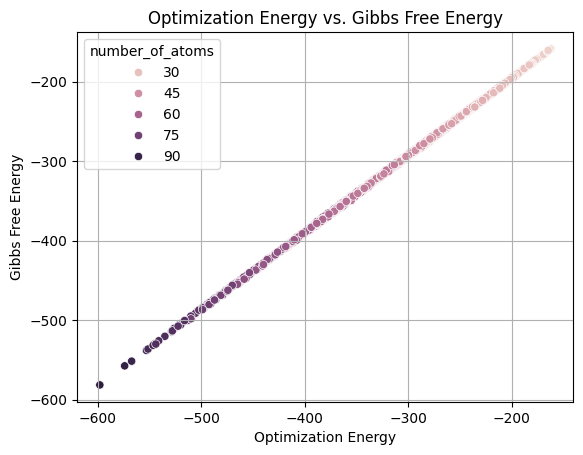

In [14]:
sns.scatterplot(data=df, x='opt_energy_eV', y='G_eV (Gibbs Free Energy)', hue='number_of_atoms')
plt.title('Optimization Energy vs. Gibbs Free Energy')
plt.xlabel('Optimization Energy')
plt.ylabel('Gibbs Free Energy')
plt.grid(True)
plt.show()

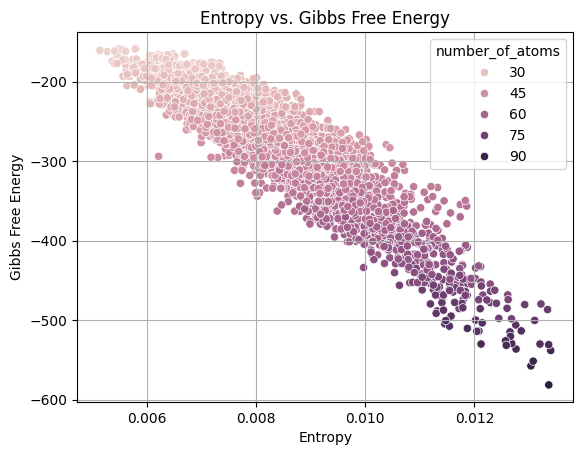

In [15]:
sns.scatterplot(data=df, x='S_eV/K (Entropy)', y='G_eV (Gibbs Free Energy)', hue='number_of_atoms')
plt.title('Entropy vs. Gibbs Free Energy')
plt.xlabel('Entropy')
plt.ylabel('Gibbs Free Energy')
plt.grid(True)
plt.show()

#### 2.2. Heatmap

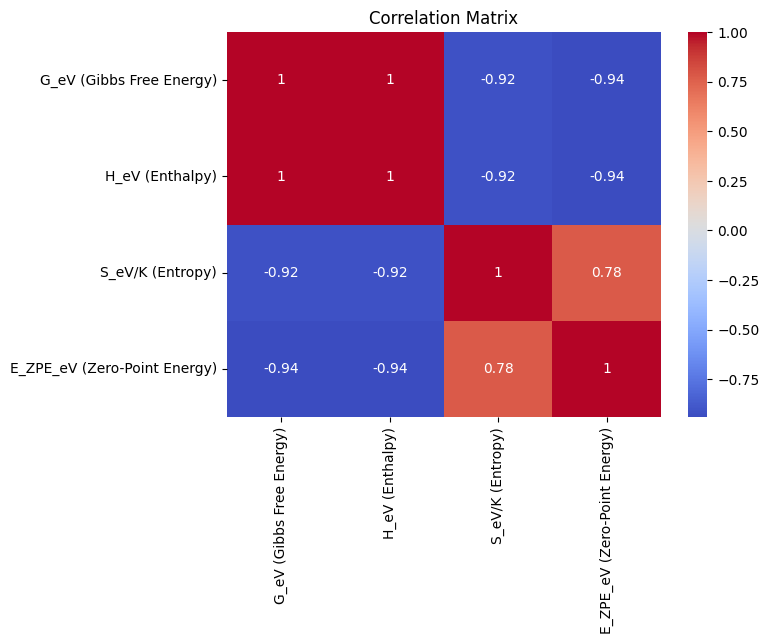

In [16]:
heatmap_variables = ['G_eV (Gibbs Free Energy)', 'H_eV (Enthalpy)', 'S_eV/K (Entropy)', 'E_ZPE_eV (Zero-Point Energy)']
plt.figure(figsize=(7, 5))
sns.heatmap(df[heatmap_variables].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### 2.3. Element Histograms

In [17]:
# Find out what elements are in the molecules

import re

elements = [re.findall(r'[A-Z][a-z]?', formula) for formula in df['formula']]

all_elements = []
unique_elements = []

for x in elements:
    if x not in all_elements:
        all_elements.extend(x)

for x in all_elements:
  if x not in unique_elements:
    unique_elements.append(x)

print(unique_elements)

['C', 'H', 'F', 'N', 'Ni', 'O', 'Cl']


In [18]:
df['has_Cl'] = df['formula'].str.contains('Cl', na=False)
df['has_F'] = df['formula'].str.contains('F', na=False)

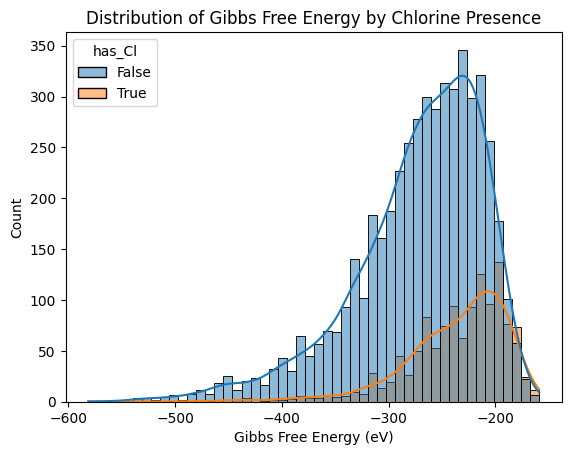

In [19]:
sns.histplot(data=df, x='G_eV (Gibbs Free Energy)', hue='has_Cl', kde=True, bins=50)
plt.title('Distribution of Gibbs Free Energy by Chlorine Presence')
plt.xlabel('Gibbs Free Energy (eV)')
plt.show()

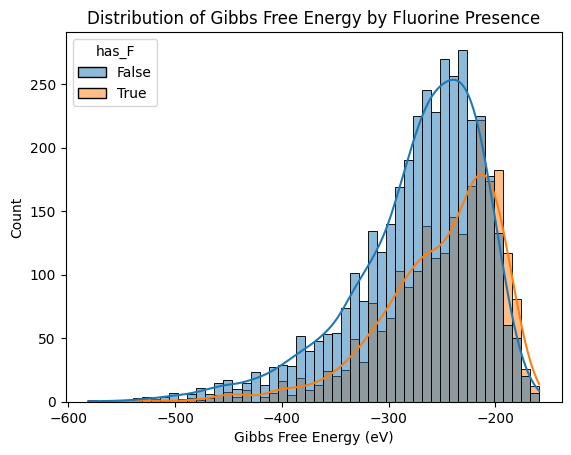

In [20]:
sns.histplot(data=df, x='G_eV (Gibbs Free Energy)', hue='has_F', kde=True, bins=50)
plt.title('Distribution of Gibbs Free Energy by Fluorine Presence')
plt.xlabel('Gibbs Free Energy (eV)')
plt.show()

#### 2.4. Frequency Histograms

##### Parse

In [21]:
def parse_frequencies(freq_list):
    real = [f['real'] for f in freq_list if 'real' in f]
    imag = [f['imag'] for f in freq_list if 'imag' in f]
    return pd.Series([real, imag])

In [22]:
df[['real_frequencies', 'imaginary_frequencies']] = df['frequencies_cm^-1'].apply(parse_frequencies)

In [23]:
df[['real_frequencies', 'imaginary_frequencies']].head()

,real_frequencies,imaginary_frequencies
0,"[0.0, 0.0, 0.0, 0.15866612590208973, 0.4749786...","[2.2749064103620245, 0.7016596889158797, 0.184..."
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.44872301722175917,...","[53.60761545618465, 3.019833187152063, 0.83337..."
2,"[0.0, 0.0, 0.0, 0.0, 0.1381566271295377, 0.405...","[63.90130641167223, 2.4691004997643264, 1.2841..."
3,"[0.0, 0.0, 0.0, 0.05025494281289923, 0.1772908...","[1.9451131105921224, 0.8535620313329322, 0.142..."
4,"[0.0, 0.0, 0.0, 0.0, 0.02890507046263699, 0.14...","[4.182615803428762, 2.7930441476705883, 1.9105..."


##### Real

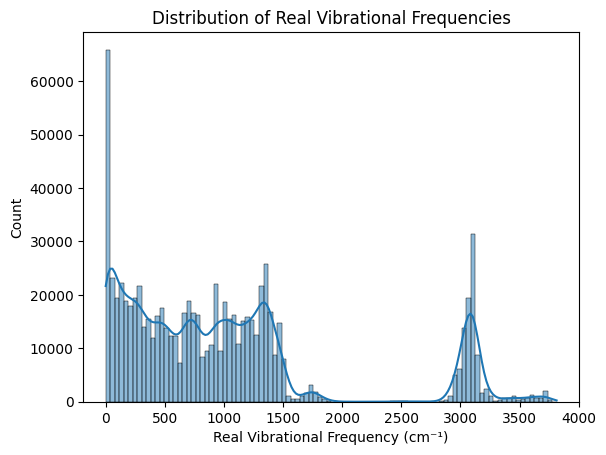

In [24]:
all_real_freqs = [freq for sublist in df['real_frequencies'] for freq in sublist]

sns.histplot(all_real_freqs, bins=100, kde=True)
plt.xlabel("Real Vibrational Frequency (cm⁻¹)")
plt.ylabel("Count")
plt.title("Distribution of Real Vibrational Frequencies")
plt.show()

##### Imaginary

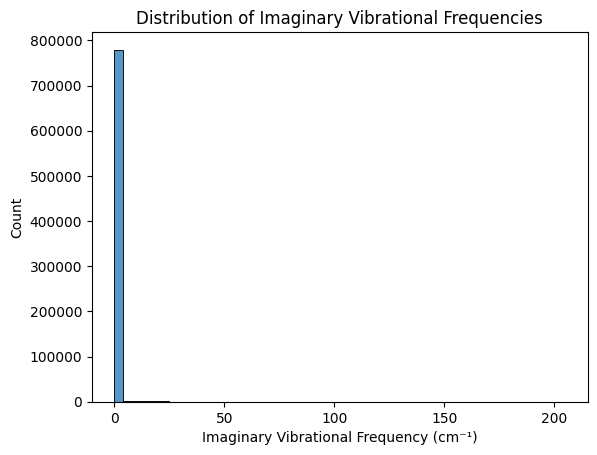

In [25]:
all_imag_freqs = [freq for sublist in df['imaginary_frequencies'] for freq in sublist]

sns.histplot(all_imag_freqs, bins=50)
plt.xlabel("Imaginary Vibrational Frequency (cm⁻¹)")
plt.ylabel("Count")
plt.title("Distribution of Imaginary Vibrational Frequencies")
plt.show()

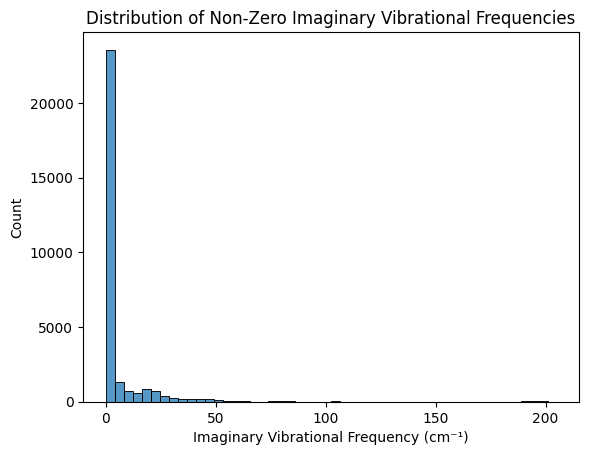

In [26]:
nonzero_imag_freqs = [freq for freq in all_imag_freqs if abs(freq) > 0]

sns.histplot(nonzero_imag_freqs, bins=50)
plt.xlabel("Imaginary Vibrational Frequency (cm⁻¹)")
plt.ylabel("Count")
plt.title("Distribution of Non-Zero Imaginary Vibrational Frequencies")
plt.show()

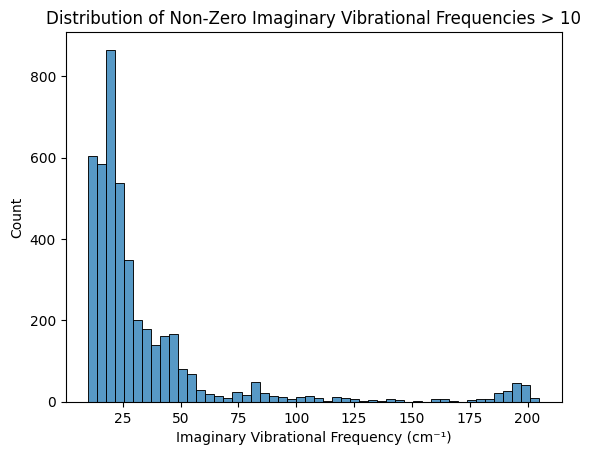

In [27]:
nonzero_imag_freqs = [freq for freq in all_imag_freqs if abs(freq) > 10]

sns.histplot(nonzero_imag_freqs, bins=50)
plt.xlabel("Imaginary Vibrational Frequency (cm⁻¹)")
plt.ylabel("Count")
plt.title("Distribution of Non-Zero Imaginary Vibrational Frequencies > 10")
plt.show()